# 🎬 Cinema Scoops — Movie Data Analysis

**Objective:** Analyze movie trends, ratings, popularity, and genres using NumPy, Pandas, Matplotlib, and Seaborn.

**Dataset:** `mymoviedb.csv` — 9,837 movies with 9 features including Title, Popularity, Vote Count, Vote Average, Genre, Language, and Release Date.

---
## Table of Contents
1. Data Loading
2. Data Cleaning
3. Descriptive Statistics
4. Visual Analysis
5. Key Insights

---
## 1. Data Loading

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


In [2]:
# Load dataset — checks both relative and current directory
for path in ["../data/mymoviedb.csv", "mymoviedb.csv"]:
    if os.path.exists(path):
        df = pd.read_csv(path, engine='python', on_bad_lines='skip')
        print(f"Dataset loaded from: {path}")
        break
else:
    raise FileNotFoundError("mymoviedb.csv not found. Place it in the same folder or ../data/")

Dataset loaded from: ../data/mymoviedb.csv


In [3]:
# Q1. What is the shape (rows, columns) of the dataset?
print("Shape:", df.shape)

Shape: (9837, 9)


In [4]:
# Q2. What are the column names and their data types?
print(df.dtypes)

Release_Date             str
Title                    str
Overview                 str
Popularity           float64
Vote_Count               str
Vote_Average             str
Original_Language        str
Genre                    str
Poster_Url               str
dtype: object


In [5]:
# Q3. Display a concise summary of the DataFrame (non-null counts, dtypes, memory)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   str    
 1   Title              9828 non-null   str    
 2   Overview           9828 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   str    
 5   Vote_Average       9827 non-null   str    
 6   Original_Language  9827 non-null   str    
 7   Genre              9826 non-null   str    
 8   Poster_Url         9826 non-null   str    
dtypes: float64(1), str(8)
memory usage: 691.8 KB


In [6]:
# Q4. Show the first 10 rows of the dataset
df.head(10)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
5,2022-01-07,The Commando,An elite DEA agent returns home after a failed...,1750.484,33,6.6,en,"Action, Crime, Thriller",https://image.tmdb.org/t/p/original/pSh8MyYu5C...
6,2022-01-12,Scream,Twenty-five years after a streak of brutal mur...,1675.161,821,6.8,en,"Horror, Mystery, Thriller",https://image.tmdb.org/t/p/original/kZNHR1upJK...
7,2022-02-10,Kimi,A tech worker with agoraphobia discovers recor...,1601.782,206,6.3,en,Thriller,https://image.tmdb.org/t/p/original/okNgwtxIWz...
8,2022-02-17,Fistful of Vengeance,A revenge mission becomes a fight to save the ...,1594.013,114,5.3,en,"Action, Crime, Fantasy",https://image.tmdb.org/t/p/original/3cccEF9QZg...
9,2021-11-03,Eternals,The Eternals are a team of ancient aliens who ...,1537.406,4726,7.2,en,Science Fiction,https://image.tmdb.org/t/p/original/zByhtBvX99...


In [7]:
# Q5. Show the last 10 rows of the dataset
df.tail(10)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
9827,2005-05-18,I'm in Love With My Little Sister,Yori and his twin sister Iku used to be very c...,13.360,9,5.7,ja,"Romance, Animation, Drama",https://image.tmdb.org/t/p/original/fRdxgR85XX...
9828,2013-08-23,All Is Lost,"During a solo voyage in the Indian Ocean, a ve...",13.359,1319,6.6,en,"Action, Adventure, Drama",https://image.tmdb.org/t/p/original/9cVA4oX2xH...
9829,2008-05-13,Amateur Porn Star Killer 2,Shane Ryan's sequel to the disturbing Amateur ...,13.359,14,5.4,en,"Crime, Horror",https://image.tmdb.org/t/p/original/iBmngXVhDu...
9830,1992-06-26,Unlawful Entry,"After a break-in at their house, a couple gets...",13.358,199,6.1,en,"Crime, Thriller, Mystery",https://image.tmdb.org/t/p/original/sKUk1ca6gH...
9831,1974-11-06,The Little Prince,"Based on the story by Antoine deSaint-Exupery,...",13.357,89,6.6,en,"Science Fiction, Fantasy, Family, Music",https://image.tmdb.org/t/p/original/ts0TGlxlBf...
9832,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"Drama, Crime",https://image.tmdb.org/t/p/original/z81rBzHNgi...
9833,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,Horror,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9834,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"Mystery, Thriller, Horror",https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9835,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"Music, Drama, History",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...
9836,1984-09-23,Threads,Documentary style account of a nuclear holocau...,13.354,186,7.8,en,"War, Drama, Science Fiction",https://image.tmdb.org/t/p/original/lBhU4U9Eeh...


---
## 2. Data Cleaning

In [8]:
# Q6. How many missing values are there in each column?
df.isnull().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

In [9]:
# Q7. What percentage of values are missing per column?
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct[missing_pct > 0].round(2).to_string())

Title                0.09
Overview             0.09
Popularity           0.10
Vote_Count           0.10
Vote_Average         0.10
Original_Language    0.10
Genre                0.11
Poster_Url           0.11


In [10]:
# Q8. How many duplicate rows exist in the dataset?
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
# Q9. Remove duplicate rows and confirm the new shape
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (9837, 9)


---
## 3. Descriptive Statistics

In [12]:
# Q10. Generate summary statistics for all numeric columns
df.describe().round(2)

,Popularity
count,9827.00
mean,40.32
std,108.87
min,7.10
25%,16.13
50%,21.19
75%,35.17
max,5083.95


In [13]:
# Q11. Using NumPy — compute mean, median, standard deviation, min, max, and IQR of Popularity
popularity = np.array(df['Popularity'].dropna())

df['Popularity'].mean().round(2), df['Popularity'].median().round(2), df['Popularity'].std().round(2), \
df['Popularity'].min().round(2), df['Popularity'].max().round(2)



(np.float64(40.32),
 np.float64(21.19),
 np.float64(108.87),
 np.float64(7.1),
 np.float64(5083.95))

In [14]:
# Q12. What are the 25th, 50th, and 75th percentiles of Popularity?
p25, p50, p75 = np.percentile(popularity, [25, 50, 75])
print(f"25th percentile: {p25:.3f}")
print(f"50th percentile: {p50:.3f}")
print(f"75th percentile: {p75:.3f}")

25th percentile: 16.127
50th percentile: 21.191
75th percentile: 35.174


In [15]:
# Q13. Which movie has the highest popularity score?
df.loc[df['Popularity'].idxmax(), ['Title', 'Popularity', 'Vote_Average', 'Genre']]

Title                      Spider-Man: No Way Home
Popularity                                5083.954
Vote_Average                                   8.3
Genre           Action, Adventure, Science Fiction
Name: 0, dtype: object

In [16]:
# Q14. What is the most frequent genre? Show the top 10 genre counts
print("Most common genre:", df['Genre'].mode()[0])
print("\nTop 10 genres:")
print(df['Genre'].value_counts().head(10).to_string())

Most common genre: Drama

Top 10 genres:
Genre
Drama                     466
Comedy                    403
Drama, Romance            248
Horror                    238
Horror, Thriller          199
Comedy, Romance           196
Documentary               139
Comedy, Drama             137
Action, Thriller          125
Comedy, Drama, Romance    107


---
## 4. Visual Analysis

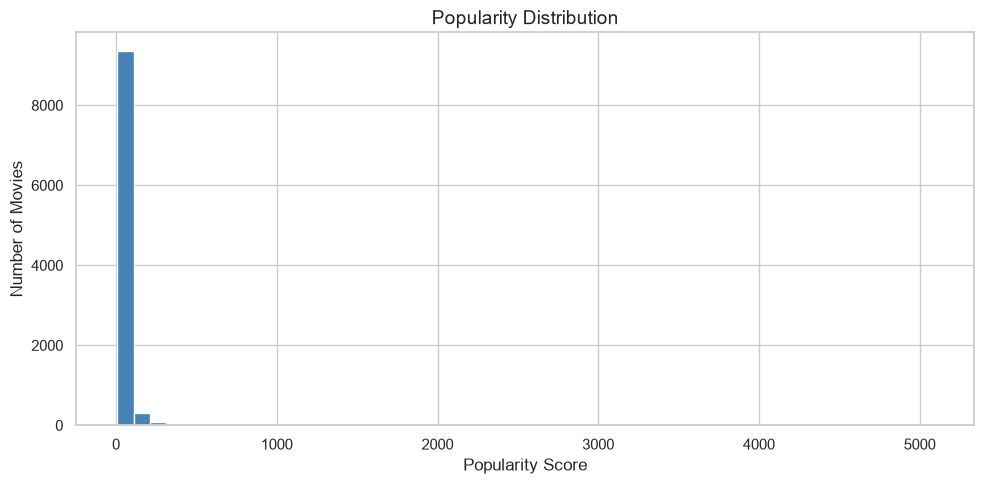

In [17]:
# Q15. [Matplotlib] Plot the distribution of Popularity scores
plt.figure(figsize=(10, 5))
plt.hist(df['Popularity'], bins=50, color='steelblue', edgecolor='white')
plt.title('Popularity Distribution', fontsize=14)
plt.xlabel('Popularity Score')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('../images/popularity_distribution.png', bbox_inches='tight')
plt.show()

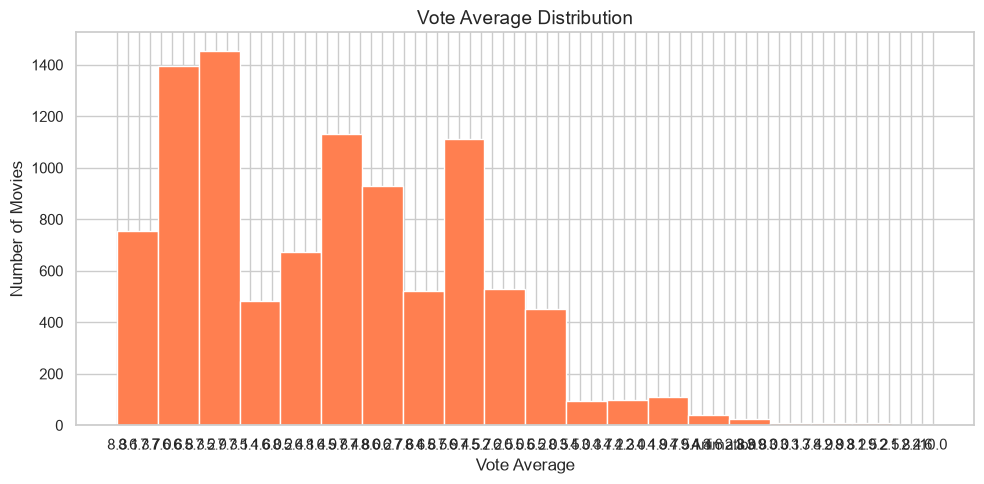

In [18]:
# Q16. [Matplotlib] Plot the distribution of Vote Average (ratings)
plt.figure(figsize=(10, 5))
plt.hist(df['Vote_Average'].dropna(), bins=20, color='coral', edgecolor='white')
plt.title('Vote Average Distribution', fontsize=14)
plt.xlabel('Vote Average')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('../images/rating_distribution.png', bbox_inches='tight')
plt.show()

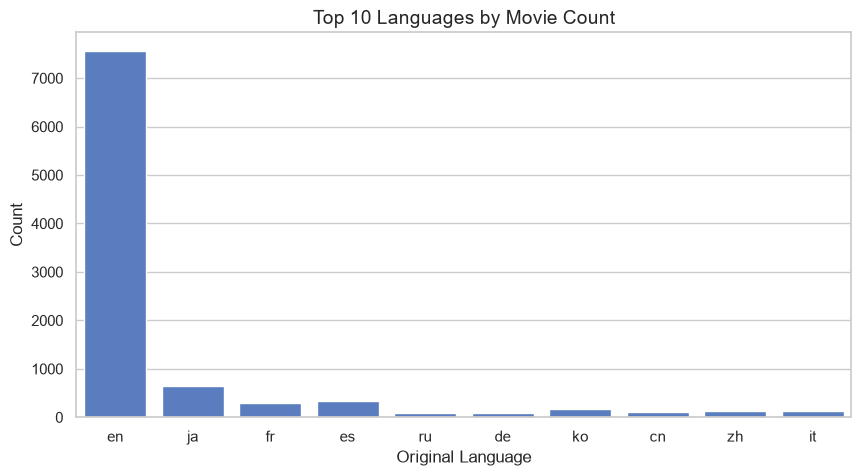

In [19]:
# Q17. [Seaborn] Countplot — what are the most common languages in the dataset?
plt.figure(figsize=(10, 5))
top_langs = df['Original_Language'].value_counts().head(10).index
sns.countplot(
    data=df[df['Original_Language'].isin(top_langs)],
    x='Original_Language',
    
)
plt.title('Top 10 Languages by Movie Count', fontsize=14)
plt.xlabel('Original Language')
plt.ylabel('Count')

plt.savefig('../images/language_distribution.png', bbox_inches='tight')
plt.show()

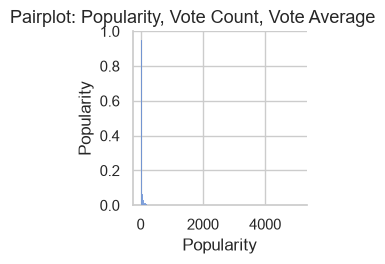

In [20]:
# Q18. [Seaborn] Pairplot — explore relationships among Popularity, Vote Count, and Vote Average
sns.pairplot(df[['Popularity', 'Vote_Count', 'Vote_Average']].dropna(), plot_kws={'alpha': 0.3})
plt.suptitle('Pairplot: Popularity, Vote Count, Vote Average', y=1.02, fontsize=13)
plt.savefig('../images/pairplot.png', bbox_inches='tight')
plt.show()

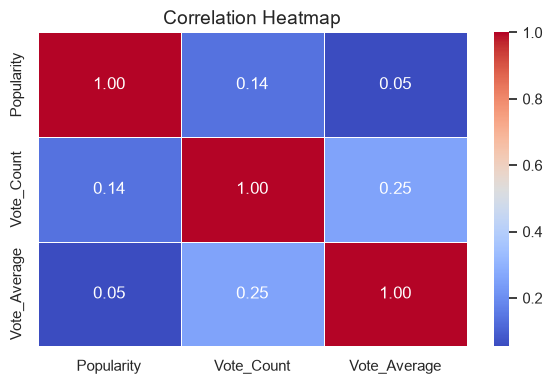

In [21]:
# Q19. [Seaborn] Heatmap
df['Vote_Count']   = pd.to_numeric(df['Vote_Count'],   errors='coerce')
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')

corr = df[['Popularity', 'Vote_Count', 'Vote_Average']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('../images/heatmap.png', bbox_inches='tight')
plt.show()

---
## 5. Key Insights

In [22]:
# Q20. What is the most popular movie, and how far is it from the average popularity?
top_movie = df.loc[df['Popularity'].idxmax()]
avg_pop    = df['Popularity'].mean()
print(f"Most popular movie : {top_movie['Title']}")
print(f"Its popularity     : {top_movie['Popularity']:.2f}")
print(f"Dataset average    : {avg_pop:.2f}")
print(f"It is {top_movie['Popularity'] / avg_pop:.1f}x more popular than the average movie.")

Most popular movie : Spider-Man: No Way Home
Its popularity     : 5083.95
Dataset average    : 40.32
It is 126.1x more popular than the average movie.


In [23]:
# Q21. Which genre produces the highest average popularity score?
genre_popularity = df.groupby('Genre')['Popularity'].mean().sort_values(ascending=False)
print("Top 5 genres by average popularity:")
print(genre_popularity.head(5).round(2).to_string())

Top 5 genres by average popularity:
Genre
Animation, Family, Fantasy, Comedy, Adventure    1373.78
Action, Crime, Fantasy                            841.06
Animation, Comedy, Family, Music                  626.98
Animation, Comedy, Family, Western                614.11
Animation, Drama, Comedy, Horror                  551.65


In [24]:
# Q22. Which year had the highest total Popularity score?
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['Release_Year'] = df['Release_Date'].dt.year

year_pop = df.groupby('Release_Year')['Popularity'].sum().sort_values(ascending=False)
print("Top 5 years by total Popularity:")
print(year_pop.head(5).round(2).to_string())

Top 5 years by total Popularity:
Release_Year
2021.0    82290.38
2022.0    46564.41
2020.0    19112.95
2019.0    17442.61
2017.0    15908.66


**Key Findings**

In [25]:
# Q23. Summary — print a clean key findings report
top_movie   = df.loc[df['Popularity'].idxmax(), 'Title']
top_lang    = df['Original_Language'].mode()[0]
top_genre   = df['Genre'].mode()[0]
median_pop  = round(np.median(popularity), 3)
max_pop     = round(np.max(popularity), 3)
corr_vc_va  = round(df['Vote_Count'].corr(df['Vote_Average']), 2)

print("=" * 50)
print("       CINEMA SCOOPS — KEY FINDINGS")
print("=" * 50)
print(f"1. Most popular movie     : {top_movie}")
print(f"2. Most common language   : {top_lang}")
print(f"3. Most frequent genre    : {top_genre}")
print(f"4. Median popularity      : {median_pop}")
print(f"5. Maximum popularity     : {max_pop}")
print(f"6. Vote_Count–Vote_Avg ρ  : {corr_vc_va}  (weak positive)")
print(f"7. Breakout hits cluster in the 6.0–8.5 rating sweet spot")
print(f"8. A viral popularity spike triggers exponential Vote_Count growth")
print("=" * 50)

       CINEMA SCOOPS — KEY FINDINGS
1. Most popular movie     : Spider-Man: No Way Home
2. Most common language   : en
3. Most frequent genre    : Drama
4. Median popularity      : 21.191
5. Maximum popularity     : 5083.954
6. Vote_Count–Vote_Avg ρ  : 0.25  (weak positive)
7. Breakout hits cluster in the 6.0–8.5 rating sweet spot
8. A viral popularity spike triggers exponential Vote_Count growth
